In [48]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [49]:
df=pd.read_csv('gurgaon_properties_missing_value_imputation.csv')

In [50]:
df.shape

(3639, 18)

In [51]:
df.head()

,property_type,society,sector,price,price_per_sqft,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,gls avenue,sector 92,0.21,6954.0,1.0,1,1,0.0,Relatively New,336.0,0,0,0,0,0,0,63
1,flat,paras quartier,sector 59,5.90,11028.0,4.0,4,3+,0.0,Moderately old,5350.0,0,0,0,0,0,0,63
2,flat,hsiidc sidco aravali,sector 1,0.90,3477.0,3.0,3,3+,8.0,Moderately old,1900.0,0,0,0,0,0,0,23
3,house,sector 15 part 2 rwa,sector 15,10.00,22120.0,5.0,5,2,2.0,Old Property,4518.0,0,0,0,0,0,0,49
4,flat,eldeco accolade,sector 48,0.72,4975.0,2.0,2,3+,12.0,Relatively New,1165.0,0,0,0,0,0,0,152


In [52]:
train_df=df.drop(columns=['society','price_per_sqft'])

In [53]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 92,0.21,1.0,1,1,0.0,Relatively New,336.0,0,0,0,0,0,0,63
1,flat,sector 59,5.90,4.0,4,3+,0.0,Moderately old,5350.0,0,0,0,0,0,0,63
2,flat,sector 1,0.90,3.0,3,3+,8.0,Moderately old,1900.0,0,0,0,0,0,0,23
3,house,sector 15,10.00,5.0,5,2,2.0,Old Property,4518.0,0,0,0,0,0,0,49
4,flat,sector 48,0.72,2.0,2,3+,12.0,Relatively New,1165.0,0,0,0,0,0,0,152


In [54]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3639 entries, 0 to 3638
Data columns (total 16 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   property_type    3639 non-null   object 
 1   sector           3639 non-null   object 
 2   price            3639 non-null   float64
 3   bedRoom          3639 non-null   float64
 4   bathroom         3639 non-null   int64  
 5   balcony          3639 non-null   object 
 6   floorNum         3639 non-null   float64
 7   agePossession    3639 non-null   object 
 8   built_up_area    3639 non-null   float64
 9   study room       3639 non-null   int64  
 10  servent room     3639 non-null   int64  
 11  store room       3639 non-null   int64  
 12  pooja room       3639 non-null   int64  
 13  others           3639 non-null   int64  
 14  furnishing_type  3639 non-null   int64  
 15  luxury_score     3639 non-null   int64  
dtypes: float64(4), int64(8), object(4)
memory usage: 455.0+ KB


<Axes: >

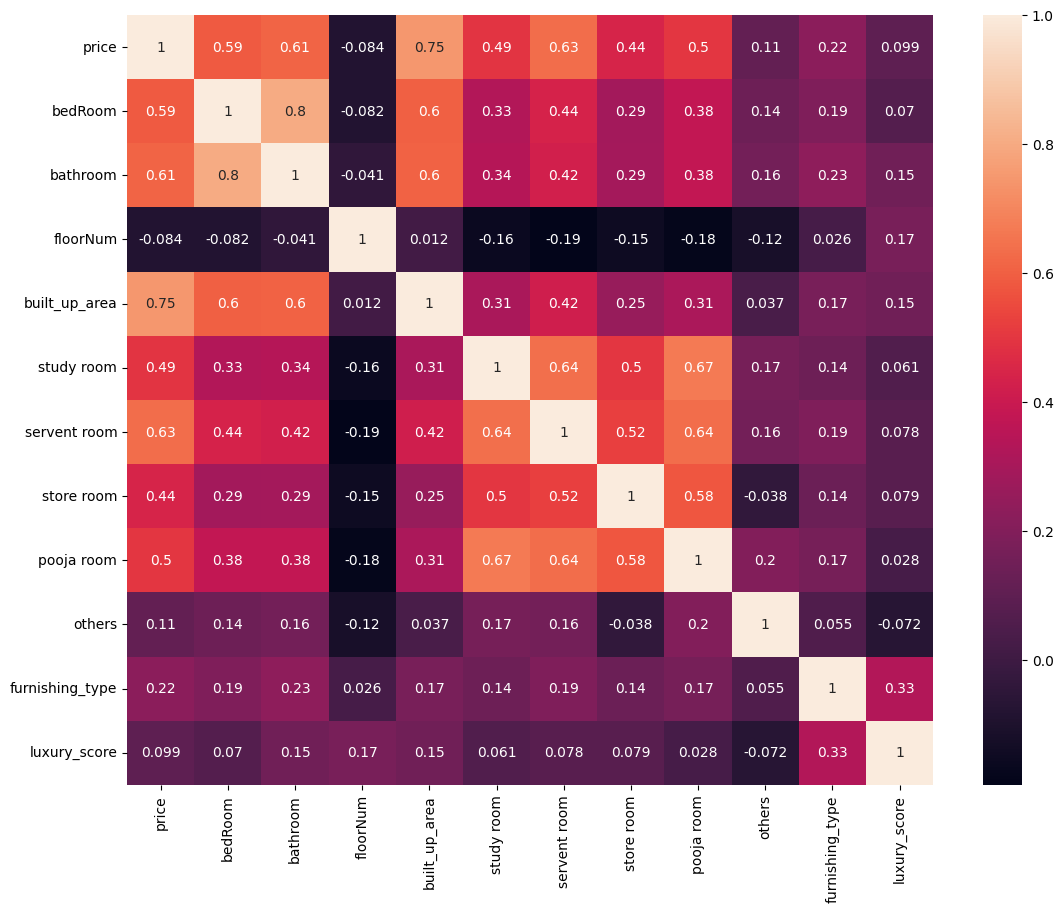

In [55]:
corr=train_df.select_dtypes('number').corr()
plt.figure(figsize=(13,10))
sns.heatmap(corr,annot=True)

In [56]:
corr['price'].sort_values(ascending=False)

price              1.000000
built_up_area      0.745933
servent room       0.634820
bathroom           0.608669
bedRoom            0.585415
pooja room         0.500358
study room         0.492794
store room         0.440371
furnishing_type    0.221821
others             0.109309
luxury_score       0.098713
floorNum          -0.083912
Name: price, dtype: float64

In [57]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score
0,flat,sector 92,0.21,1.0,1,1,0.0,Relatively New,336.0,0,0,0,0,0,0,63
1,flat,sector 59,5.90,4.0,4,3+,0.0,Moderately old,5350.0,0,0,0,0,0,0,63
2,flat,sector 1,0.90,3.0,3,3+,8.0,Moderately old,1900.0,0,0,0,0,0,0,23
3,house,sector 15,10.00,5.0,5,2,2.0,Old Property,4518.0,0,0,0,0,0,0,49
4,flat,sector 48,0.72,2.0,2,3+,12.0,Relatively New,1165.0,0,0,0,0,0,0,152


# luxury Score

<Axes: xlabel='luxury_score'>

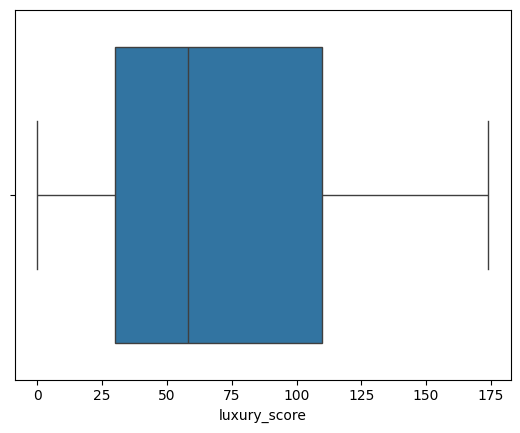

In [58]:
sns.boxplot(x=train_df['luxury_score'])

In [59]:
def categorize_luxury(score):
    if 0<=score<50:
        return 'Low'
    elif 50<=score<150:
        return 'Medium'
    else:
        return "High"

In [60]:
train_df['luxury_category']=train_df['luxury_score'].apply(categorize_luxury)

<Axes: xlabel='floorNum'>

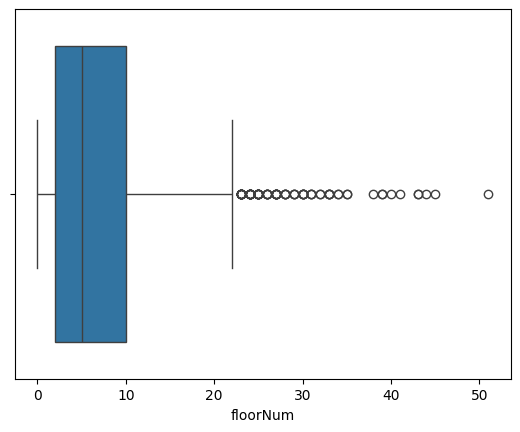

In [61]:
sns.boxplot(x=train_df['floorNum'])

In [62]:
def categorize_floor(floor):
    if 0<=floor<=2:
        return "Low Floor"
    elif 3<= floor <=10:
        return "Mid Floor"
    elif 11<= floor<=51:
        return "High Floor"
    else:
        return None

In [63]:
train_df['floor_category']=train_df['floorNum'].apply(categorize_floor)

In [64]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,floorNum,agePossession,built_up_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_score,luxury_category,floor_category
0,flat,sector 92,0.21,1.0,1,1,0.0,Relatively New,336.0,0,0,0,0,0,0,63,Medium,Low Floor
1,flat,sector 59,5.90,4.0,4,3+,0.0,Moderately old,5350.0,0,0,0,0,0,0,63,Medium,Low Floor
2,flat,sector 1,0.90,3.0,3,3+,8.0,Moderately old,1900.0,0,0,0,0,0,0,23,Low,Mid Floor
3,house,sector 15,10.00,5.0,5,2,2.0,Old Property,4518.0,0,0,0,0,0,0,49,Low,Low Floor
4,flat,sector 48,0.72,2.0,2,3+,12.0,Relatively New,1165.0,0,0,0,0,0,0,152,High,High Floor


In [65]:
train_df.drop(columns=['luxury_score','floorNum'],inplace=True)

In [66]:
train_df.head()

,property_type,sector,price,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 92,0.21,1.0,1,1,Relatively New,336.0,0,0,0,0,0,0,Medium,Low Floor
1,flat,sector 59,5.90,4.0,4,3+,Moderately old,5350.0,0,0,0,0,0,0,Medium,Low Floor
2,flat,sector 1,0.90,3.0,3,3+,Moderately old,1900.0,0,0,0,0,0,0,Low,Mid Floor
3,house,sector 15,10.00,5.0,5,2,Old Property,4518.0,0,0,0,0,0,0,Low,Low Floor
4,flat,sector 48,0.72,2.0,2,3+,Relatively New,1165.0,0,0,0,0,0,0,High,High Floor


In [67]:
# spliting the dataset into traning and testing sets 
x_label=train_df.drop('price',axis=1)
y_label=train_df['price']

In [68]:
x_label

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,study room,servent room,store room,pooja room,others,furnishing_type,luxury_category,floor_category
0,flat,sector 92,1.0,1,1,Relatively New,336.0,0,0,0,0,0,0,Medium,Low Floor
1,flat,sector 59,4.0,4,3+,Moderately old,5350.0,0,0,0,0,0,0,Medium,Low Floor
2,flat,sector 1,3.0,3,3+,Moderately old,1900.0,0,0,0,0,0,0,Low,Mid Floor
3,house,sector 15,5.0,5,2,Old Property,4518.0,0,0,0,0,0,0,Low,Low Floor
4,flat,sector 48,2.0,2,3+,Relatively New,1165.0,0,0,0,0,0,0,High,High Floor
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3634,flat,sector 81,3.0,4,3+,Relatively New,2576.0,0,0,0,0,0,2,Medium,Mid Floor
3635,flat,sector 65,2.0,2,3,New Property,1045.0,0,0,0,0,0,0,Low,Mid Floor
3636,flat,sector 53,3.0,4,3+,Moderately old,2333.0,0,0,0,0,0,2,Low,Mid Floor
3637,flat,sector 76,3.0,3,3+,Relatively New,1681.0,0,0,0,0,0,2,Medium,Mid Floor


In [69]:
y_label

0        0.21
1        5.90
2        0.90
3       10.00
4        0.72
        ...  
3634     2.35
3635     2.10
3636     6.00
3637     1.05
3638     1.64
Name: price, Length: 3639, dtype: float64

In [70]:
x_label['balcony'].value_counts()

balcony
3+    1122
3     1072
2      878
1      379
0      188
Name: count, dtype: int64

In [71]:
# now we are going to make 8 feature selection technique and in 
# each feature section technique we are going to give an score to aur every feature 
# and at the end we can calculate avg score (or sum of all the score of that feature) off ech feature and which features has more agv score  that means they are more importnat feature  

 # 1. Correlation Analysis

<Axes: >

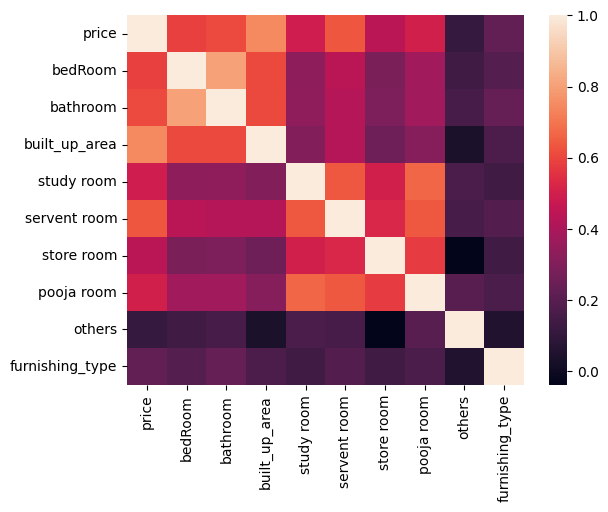

In [72]:
corr=train_df.select_dtypes('number')
sns.heatmap(corr.corr())

In [74]:
fi_df1=corr.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coef'})

In [75]:
fi_df1

,feature,corr_coef
0,bedRoom,0.585415
1,bathroom,0.608669
2,built_up_area,0.745933
3,study room,0.492794
4,servent room,0.634820
5,store room,0.440371
6,pooja room,0.500358
7,others,0.109309
8,furnishing_type,0.221821


In [81]:
train_df[['property_type','sector','price','bedRoom','bathroom'	,'balcony','agePossession','built_up_area','servent room','store room','furnishing_type','luxury_category','floor_category']].to_csv('gurgaon_properties_post_feature_selection_v2.csv',index=False)

# 2. Random Forest Feature Importance

In [76]:
from sklearn.ensemble import RandomForestRegressor
rf_label=RandomForestRegressor(n_estimators=100,random_state=42)
rf_label.fit(x_label,y_label)
fi_df2=pd.DataFrame({'feature':x_label.columns,
                    'rf_importance':rf_label.feature_importances_}).sort_values(by='rf_importance',ascending=False)
fi_df2

ValueError: could not convert string to float: 'flat'

# 3. Gradient Boosting Feature importances

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
gb_label=GradientBoostingRegressor()
gb_label.fit(x_label,y_label)

fi_df3=pd.DataFrame({'feature':x_label.columns,
                    "gb_importance":gb_label.feature_importances_
                    }).sort_values(by='gb_importance',ascending=False)
fi_df3

# 4. Permutation Importance

In [ ]:
from sklearn.inspection import permutation_importance
from sklearn.model_selection import train_test_split
X_train_label,X_test_label,y_train_label,y_test_label=train_test_split(x_label,y_label,test_size=0.2,random_state=42)
# Train a Random Forest regressor on label encoded data like a base model 
rf_label=RandomForestRegressor(n_estimators=100,random_state=42)
rf_label.fit(X_train_label,y_train_label)
# Calculate Permutation Importance
perm_importance= permutation_importance(rf_label,X_test_label,y_test_label,n_repeats=30,random_state=42)
# Organize results into a Dataframe
fi_df4=pd.DataFrame({
    'feature':x_label.columns,
    'permutation_importance':perm_importance.importances_mean
}).sort_values(by='permutation_importance',ascending=False) 
fi_df4

# 5. Lasso

In [ ]:
from sklearn.linear_model  import Lasso
from sklearn.preprocessing  import StandardScaler
scaler=StandardScaler()
X_scaled=scaler.fit_transform(x_label)
lasso=Lasso(alpha=0.01,random_state=42)
lasso.fit(X_scaled,y_label)
fi_df5=pd.DataFrame({
    'feature':x_label.columns,
    'lasso_coeff':lasso.coef_
}).sort_values(by='lasso_coeff',ascending=False)
fi_df5

# 6. RFE

In [ ]:
from sklearn.feature_selection import RFE
from sklearn.ensemble import RandomForestRegressor
# Here for estimation we use Tree model
estimator=RandomForestRegressor()
# Apply Rfe on label encoded and standerdize data
selector_label=RFE(estimator,n_features_to_select=x_label.shape[1],step=1)
# fit data in RFE Model
selector_label.fit(x_label,y_label)
# get important Feature name
selected_features=x_label.columns[selector_label.support_]
# get important feature importance value
selected_coefficients=selector_label.estimator_.feature_importances_
# make dataframe 
fi_df6=pd.DataFrame({
    'feature':selected_features,
    'rfe_score':selected_coefficients
}).sort_values(by='rfe_score', ascending=False)

fi_df6



# 7. Linear Regression Weights

In [ ]:
from sklearn.linear_model import LinearRegression
lin_reg=LinearRegression()
lin_reg.fit(X_scaled,y_label)
fi_df7=pd.DataFrame({
    'feature':x_label.columns,
    'reg_coeffs':lin_reg.coef_
}).sort_values(by='reg_coeffs',ascending=False)
fi_df7

# 8. SHAP (model explainbility)

In [ ]:
!pip install shap

In [ ]:
import shap
rf_label=RandomForestRegressor(n_estimators=100,random_state=42)
rf_label.fit(x_label,y_label)
explainer=shap.TreeExplainer(rf_label)
shap_values=explainer.shap_values(x_label)
shap_sum=np.abs(shap_values).mean(axis=0)
shap_values

In [ ]:
fi_df8=pd.DataFrame({ 
    'feature':x_label.columns,
    'SHAP_Score':np.abs(shap_values).mean(axis=0)

}).sort_values(by='SHAP_Score',ascending=False)

In [ ]:
fi_df8

In [ ]:
data_label_encoded.corr()['price'].iloc[1:].to_frame().reset_index().rename(columns={'index':'feature','price':'corr_coef'})

In [ ]:
final_fi_df=fi_df1.merge(fi_df2,on='feature').merge(fi_df3,on='feature').merge(fi_df4,on='feature').merge(fi_df5,on='feature').merge(fi_df6,on='feature').merge(fi_df7,on='feature').merge(fi_df8,on='feature').set_index('feature')

In [ ]:
final_fi_df

In [ ]:
# normalize these scores
final_fi_df.divide(final_fi_df.sum(axis=0),axis=1)

In [ ]:
final_fi_df[['rf_importance','gb_importance','permutation_importance','rfe_score','SHAP_Score']].mean(axis=1).sort_values(ascending=False)

In [ ]:
# Apply Random Forest before droping columns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
rf=RandomForestRegressor(n_estimators=100,random_state=42)
scores=cross_val_score(rf,x_label,y_label,cv=5,scoring='r2')
scores.mean()

In [ ]:
# Apply Random Forest after droping columns
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import cross_val_score
rf=RandomForestRegressor(n_estimators=100,random_state=42)
scores=cross_val_score(rf,x_label.drop(columns=['pooja room','study room','others']),y_label,cv=5,scoring='r2')
scores.mean()

In [44]:
export_df=x_label.drop(columns=['pooja room','study room','others'])
export_df['price']=y_label

NameError: name 'x_label' is not defined

In [63]:
export_df.to_csv('gurgaon_properties_post_feature_selection.csv',index=False)

In [64]:
export_df

,property_type,sector,bedRoom,bathroom,balcony,agePossession,built_up_area,servent room,store room,furnishing_type,luxury_category,floor_category,price
0,0.0,90.0,1.0,1,1.0,3.0,336.0,0,0,0,2.0,1.0,0.21
1,0.0,56.0,4.0,4,4.0,0.0,5350.0,0,0,0,2.0,1.0,5.90
2,0.0,0.0,3.0,3,4.0,0.0,1900.0,0,0,0,1.0,2.0,0.90
3,1.0,18.0,5.0,5,2.0,2.0,4518.0,0,0,0,1.0,1.0,10.00
4,0.0,44.0,2.0,2,4.0,3.0,1165.0,0,0,0,0.0,0.0,0.72
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3634,0.0,79.0,3.0,4,4.0,3.0,2576.0,0,0,2,2.0,2.0,2.35
3635,0.0,62.0,2.0,2,3.0,1.0,1045.0,0,0,0,1.0,2.0,2.10
3636,0.0,50.0,3.0,4,4.0,0.0,2333.0,0,0,2,1.0,2.0,6.00
3637,0.0,73.0,3.0,3,4.0,3.0,1681.0,0,0,2,2.0,2.0,1.05


C:\Users\sarth\AppData\Local\Temp\ipykernel_21792\3795183576.py:2: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(x_label['built_up_area'])


<Axes: xlabel='built_up_area', ylabel='Density'>

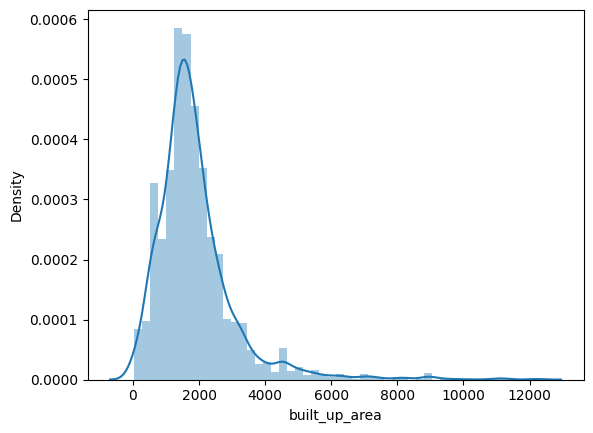

In [71]:
import seaborn as sns
sns.distplot(x_label['built_up_area'])

C:\Users\sarth\AppData\Local\Temp\ipykernel_21792\2684914680.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log1p(x_label['built_up_area']))


<Axes: xlabel='built_up_area', ylabel='Density'>

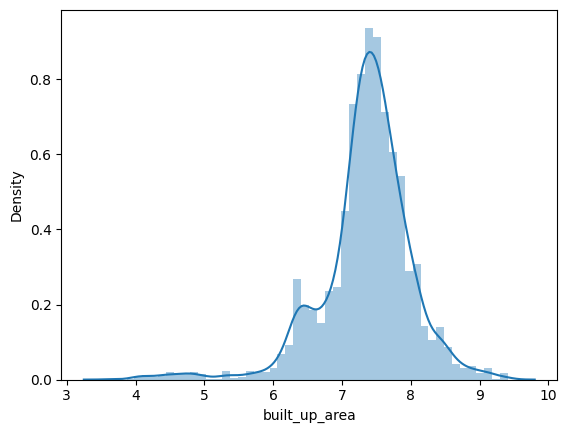

In [72]:
sns.distplot(np.log1p(x_label['built_up_area']))

C:\Users\sarth\AppData\Local\Temp\ipykernel_21792\3671818641.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(y_label)


<Axes: xlabel='price', ylabel='Density'>

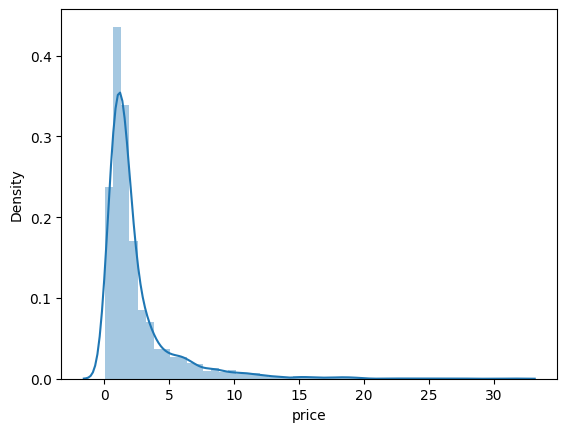

In [73]:
sns.distplot(y_label)

C:\Users\sarth\AppData\Local\Temp\ipykernel_21792\1187891710.py:1: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(np.log1p(y_label))


<Axes: xlabel='price', ylabel='Density'>

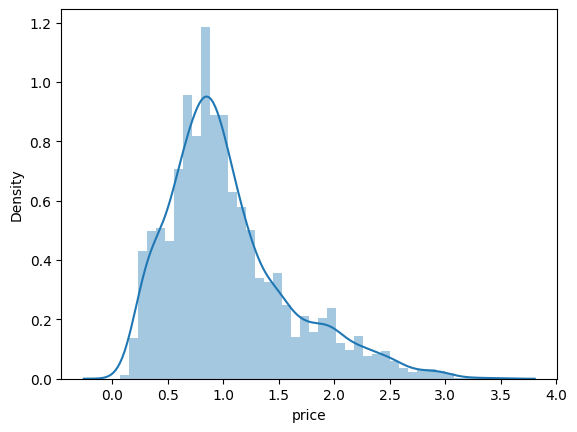

In [74]:
sns.distplot(np.log1p(y_label))